In [ ]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import matplotlib.pyplot as plt

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

db_url = f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

engine = create_engine(db_url, future=True)

print("✅ Database connection string loaded successfully!")

--------------------------------

Orders profile:
      rows  order_date_nonempty  order_date_iso_like min_order_ts  \
0  2720059              2720059              2720059   2025-03-16   

  max_order_ts  is_otd_true_like  is_otd_false_like  is_otd_other  
0   2025-09-12           2019084             535039        165936  
--------------------------------
--------------------------------

Monthly activity span:
   active_users   min_month   max_month
0        375998  2025-03-01  2025-09-01
--------------------------------
--------------------------------

Orders per month (head):
  month_start  orders_cnt
0  2025-03-01      194080
1  2025-04-01      404390
2  2025-05-01      541353
3  2025-06-01      356787
4  2025-07-01      429918
--------------------------------


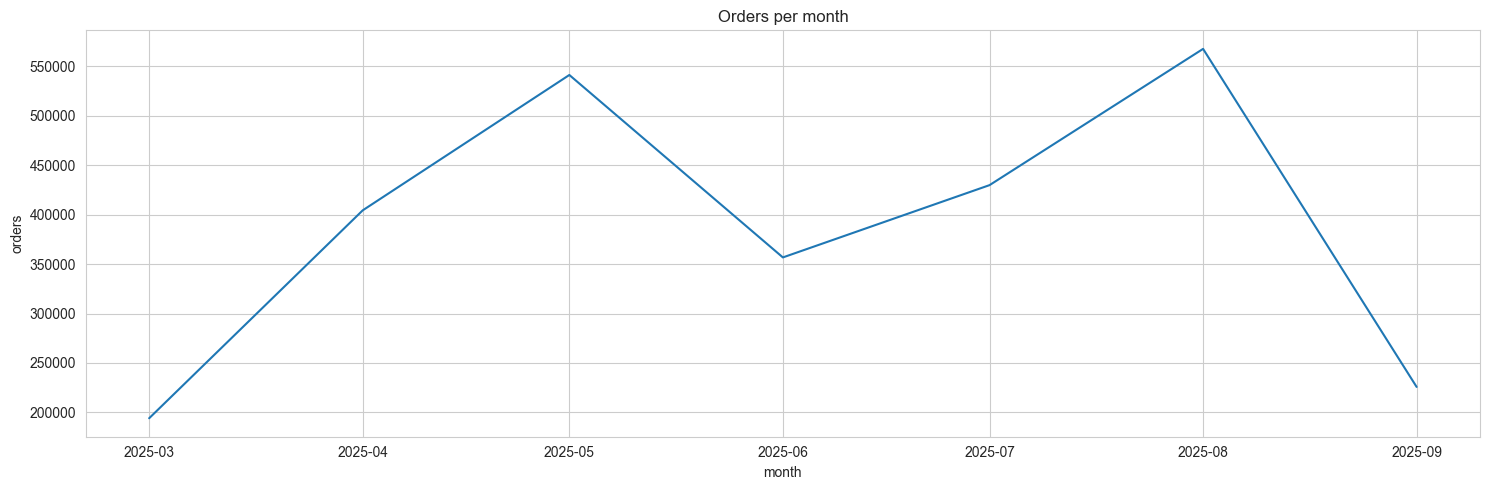

In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}", future=True)


orders_profile = r"""
SELECT
  COUNT(*) AS rows,
  COUNT(*) FILTER (WHERE NULLIF(order_date,'') <> '') AS order_date_nonempty,

  -- strings that look like ISO date/time (yyyy-mm-dd[ HH:MM[:SS]])
  COUNT(*) FILTER (
    WHERE NULLIF(order_date,'') ~ '^\d{4}-\d{2}-\d{2}([ T]\d{2}:\d{2}(:\d{2})?)?$'
  ) AS order_date_iso_like,

  -- cast only when regex matched
  MIN(
    CASE WHEN NULLIF(order_date,'') ~ '^\d{4}-\d{2}-\d{2}([ T]\d{2}:\d{2}(:\d{2})?)?$'
         THEN (order_date)::timestamp
    END
  ) AS min_order_ts,
  MAX(
    CASE WHEN NULLIF(order_date,'') ~ '^\d{4}-\d{2}-\d{2}([ T]\d{2}:\d{2}(:\d{2})?)?$'
         THEN (order_date)::timestamp
    END
  ) AS max_order_ts,

  COUNT(*) FILTER (WHERE lower(coalesce(is_otd,'')) IN ('1','true','t','yes','y')) AS is_otd_true_like,
  COUNT(*) FILTER (WHERE lower(coalesce(is_otd,'')) IN ('0','false','f','no','n'))  AS is_otd_false_like,
  COUNT(*) FILTER (WHERE coalesce(is_otd,'') NOT IN ('','0','1','true','false','t','f','yes','no','y','n')) AS is_otd_other
FROM public.orders;
"""

with engine.begin() as con:
    print("--------------------------------")
    print("\nOrders profile:")
    print(pd.read_sql(orders_profile, con))
    print("--------------------------------")


monthly_sql = r"""
WITH o AS (
  SELECT
    user_id,
    CASE
      WHEN NULLIF(order_date,'') ~ '^\d{4}-\d{2}-\d{2}([ T]\d{2}:\d{2}(:\d{2})?)?$'
      THEN (order_date)::timestamp
      ELSE NULL
    END AS order_ts
  FROM public.orders
  WHERE coalesce(user_id,'') <> ''
)
SELECT
  COUNT(DISTINCT user_id) AS active_users,
  MIN(date_trunc('month', order_ts)::date) AS min_month,
  MAX(date_trunc('month', order_ts)::date) AS max_month
FROM o
WHERE order_ts IS NOT NULL;
"""

with engine.begin() as con:
    print("--------------------------------")
    print("\nMonthly activity span:")
    print(pd.read_sql(monthly_sql, con))
    print("--------------------------------")


orders_per_month_sql = r"""
WITH o AS (
  SELECT
    CASE
      WHEN NULLIF(order_date,'') ~ '^\d{4}-\d{2}-\d{2}([ T]\d{2}:\d{2}(:\d{2})?)?$'
      THEN (order_date)::timestamp
      ELSE NULL
    END AS order_ts
  FROM public.orders
)
SELECT
  date_trunc('month', order_ts)::date AS month_start,
  COUNT(*) AS orders_cnt
FROM o
WHERE order_ts IS NOT NULL
GROUP BY 1
ORDER BY 1;
"""

df_m = pd.read_sql(orders_per_month_sql, engine, parse_dates=['month_start'])
print("--------------------------------")
print("\nOrders per month (head):")
print(df_m.head())
print("--------------------------------")

plt.figure(figsize=(15, 5))
plt.plot(df_m['month_start'], df_m['orders_cnt'])
plt.title("Orders per month")
plt.xlabel("month")
plt.ylabel("orders")
plt.tight_layout()
plt.show()

Reading user-month dataset from DB …
Shape: (879387, 16)
  user_id month_start  orders_cnt_m  otd_rate_m  late_rate_m  cancel_rate_m  \
0       1  2025-03-01             2    1.000000     0.000000            0.0   
1       1  2025-04-01             1         NaN          NaN            0.0   
2       1  2025-05-01             1    1.000000     0.000000            0.0   
3       1  2025-06-01             8    0.857143     0.142857            0.0   
4       1  2025-07-01             4    1.000000     0.000000            0.0   

   return_rate_m  crm_req_cnt_sum_m  crm_fake_cnt_sum_m  customer_rate_avg_m  \
0            0.0                  0                   0                  NaN   
1            0.0                  0                   0             5.000000   
2            0.0                  0                   0                  NaN   
3            0.0                  5                   0             4.833333   
4            0.0                  1                   0             

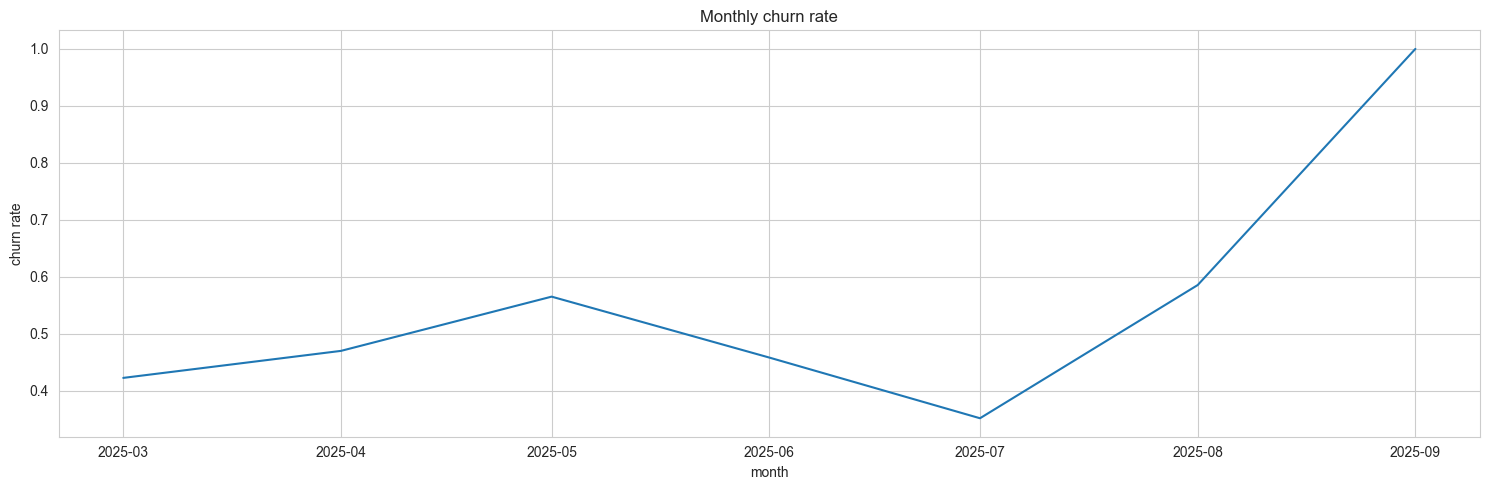


Cohort retention matrix (rows=cohort month, cols=months since):
months_since_cohort    0    1    2    3    4    5    6
cohort_month                                          
2025-03-01           1.0  1.0  1.0  1.0  1.0  1.0  1.0
2025-04-01           1.0  1.0  1.0  1.0  1.0  1.0  0.0
2025-05-01           1.0  1.0  1.0  1.0  1.0  0.0  0.0
2025-06-01           1.0  1.0  1.0  1.0  0.0  0.0  0.0
2025-07-01           1.0  1.0  1.0  0.0  0.0  0.0  0.0
2025-08-01           1.0  1.0  0.0  0.0  0.0  0.0  0.0
2025-09-01           1.0  0.0  0.0  0.0  0.0  0.0  0.0


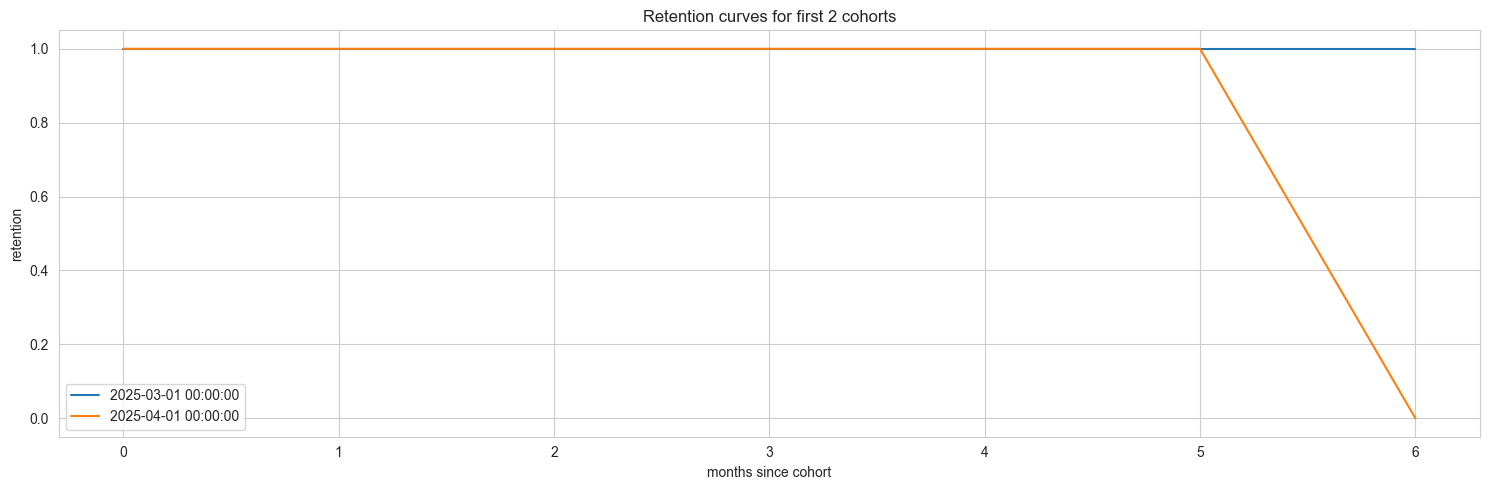


Churn rate by tenure (months since first order):
   tenure_months     label
0              0  0.671118
1              1  0.399348
2              2  0.363542
3              3  0.337237
4              4  0.400731
5              5  0.587111
6              6  1.000000


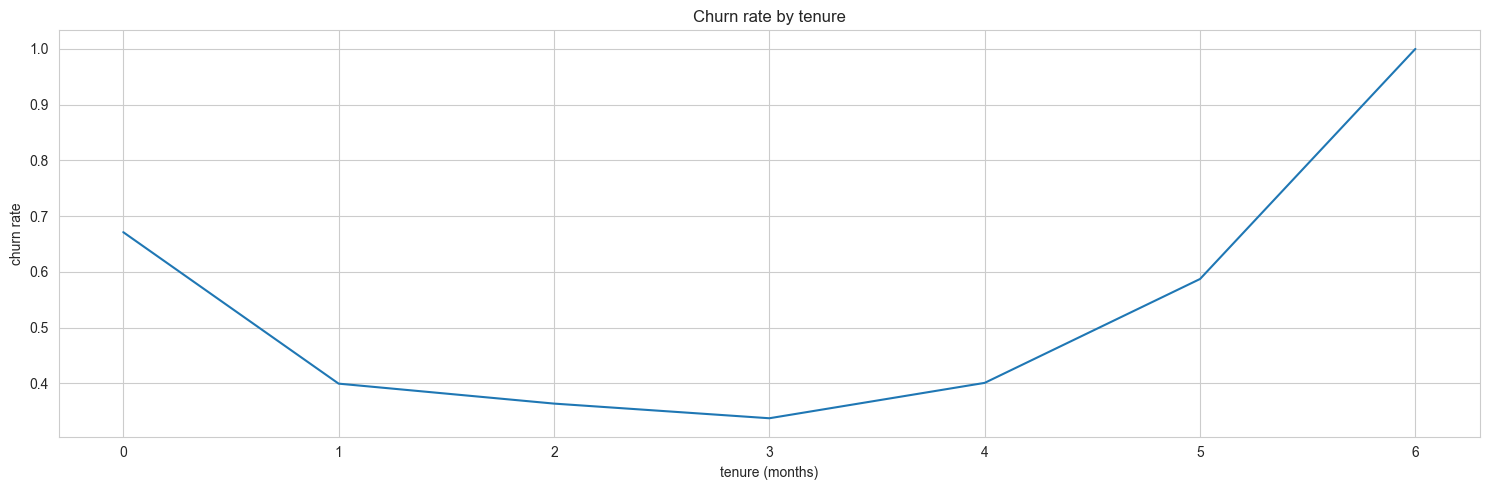

/var/folders/5z/93nvtq_954s01jydcy013dk80000gn/T/ipykernel_39229/136541067.py:246: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby('_bin')['label'].mean().reset_index()
/var/folders/5z/93nvtq_954s01jydcy013dk80000gn/T/ipykernel_39229/136541067.py:246: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby('_bin')['label'].mean().reset_index()
/var/folders/5z/93nvtq_954s01jydcy013dk80000gn/T/ipykernel_39229/136541067.py:246: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavio


Churn by orders_cnt_m deciles:
              bin  churn_rate       feature
0    (0.999, 2.0]    0.672930  orders_cnt_m
1      (2.0, 3.0]    0.420331  orders_cnt_m
2      (3.0, 4.0]    0.351456  orders_cnt_m
3      (4.0, 7.0]    0.262128  orders_cnt_m
4  (7.0, 11031.0]    0.127681  orders_cnt_m

Churn by otd_rate_m deciles:
              bin  churn_rate     feature
5  (-0.001, 0.55]    0.579072  otd_rate_m
6    (0.55, 0.75]    0.293356  otd_rate_m
7     (0.75, 1.0]    0.565500  otd_rate_m

Churn by late_rate_m deciles:
               bin  churn_rate      feature
8   (-0.001, 0.25]    0.554789  late_rate_m
9     (0.25, 0.45]    0.292509  late_rate_m
10     (0.45, 1.0]    0.579166  late_rate_m

Churn by crm_req_cnt_sum_m deciles:
              bin  churn_rate            feature
11  (-0.001, 1.0]    0.590661  crm_req_cnt_sum_m
12     (1.0, 2.0]    0.432839  crm_req_cnt_sum_m
13     (2.0, 3.0]    0.388881  crm_req_cnt_sum_m
14   (3.0, 137.0]    0.286630  crm_req_cnt_sum_m

Churn by comment

/var/folders/5z/93nvtq_954s01jydcy013dk80000gn/T/ipykernel_39229/136541067.py:246: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby('_bin')['label'].mean().reset_index()
/var/folders/5z/93nvtq_954s01jydcy013dk80000gn/T/ipykernel_39229/136541067.py:246: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby('_bin')['label'].mean().reset_index()


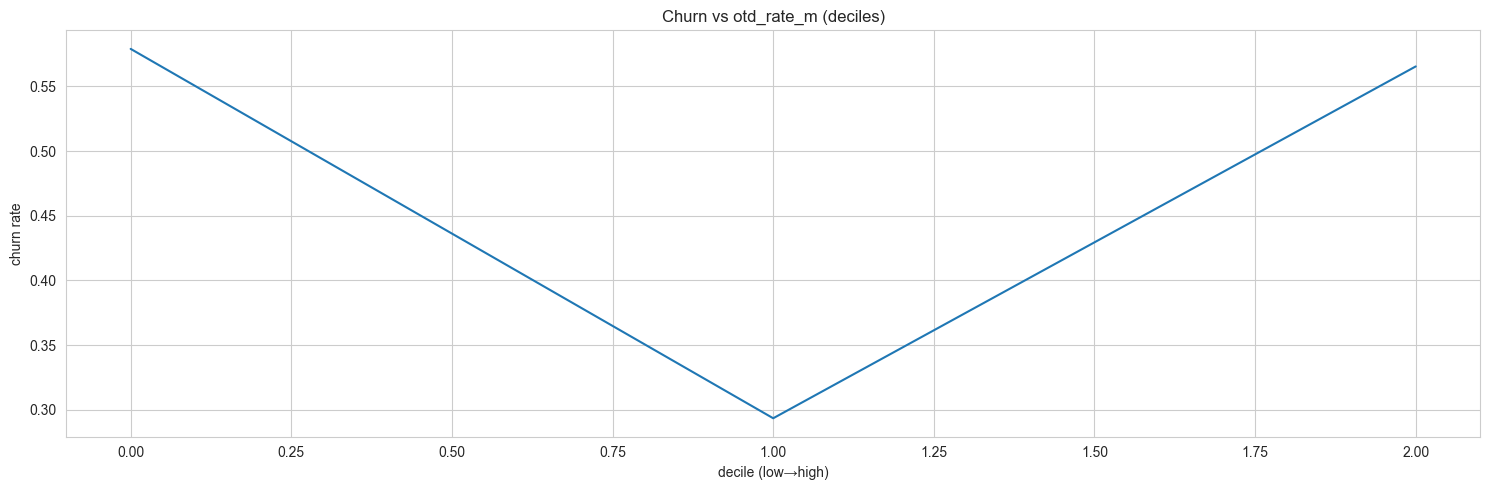

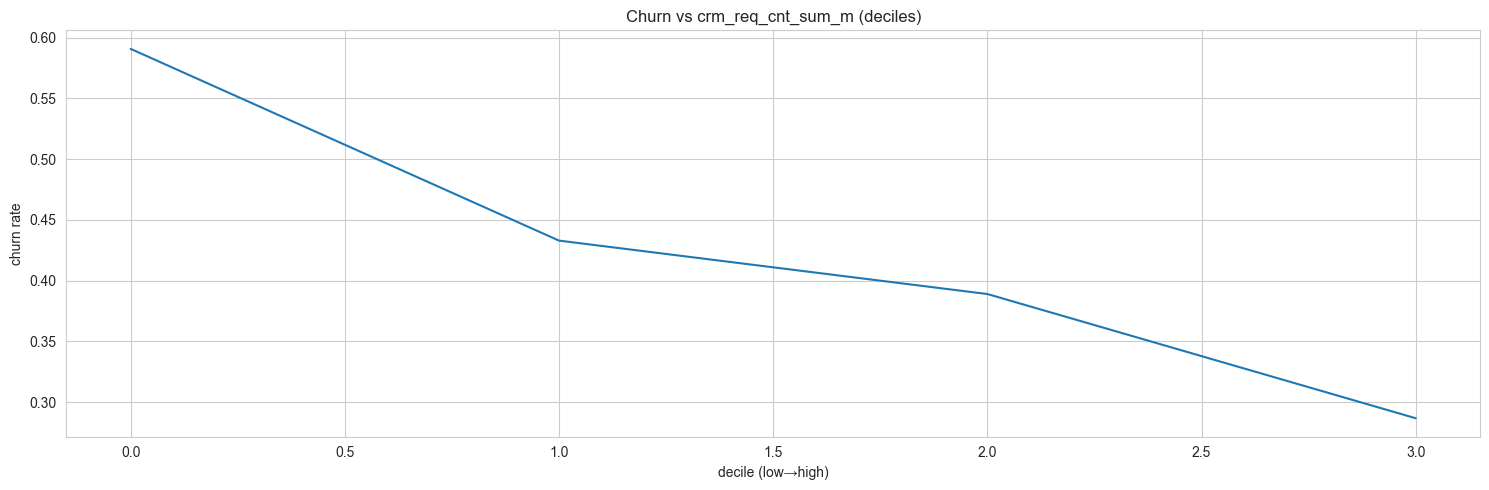

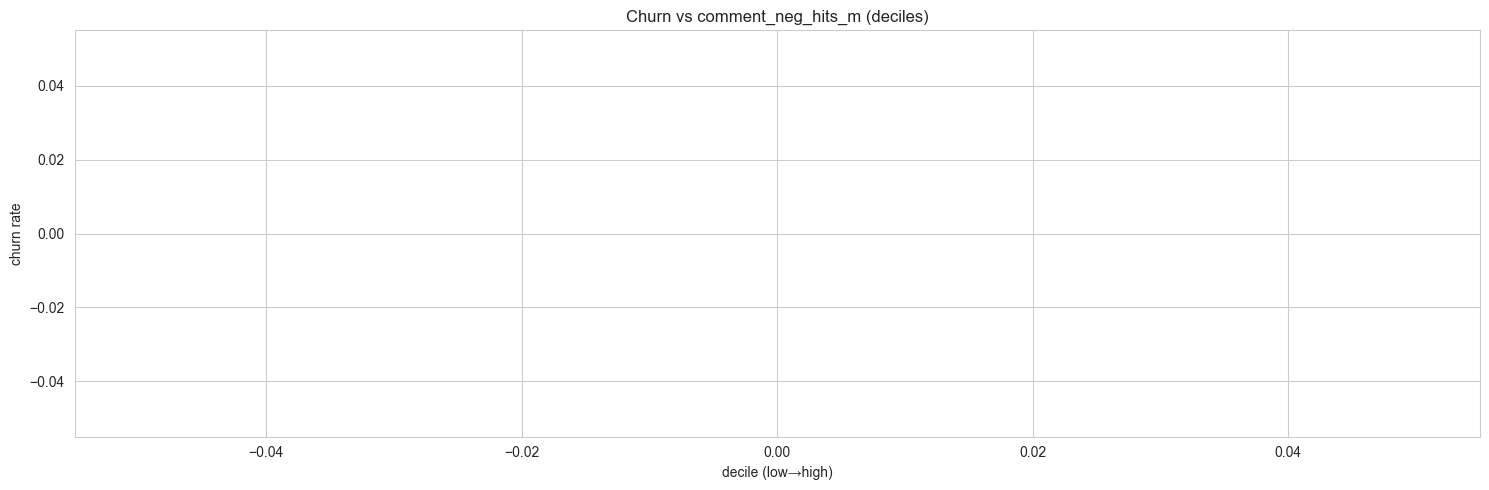

/opt/homebrew/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/lib/python3.10/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/homebrew/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/lib/python3.10/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/homebrew/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/lib/python3.10/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/5z/93nvtq_954s01jydcy013dk80000gn/T/ipykernel_39229/136541067.py:294: FutureWarni


Feature ↔ label Pearson correlations (approx point-biserial):
                feature  pearson_corr_with_label
12   comment_pos_hits_m                 0.001053
2           late_rate_m                -0.004840
1            otd_rate_m                -0.036300
6    crm_fake_cnt_sum_m                -0.065807
10    comment_avg_len_m                -0.067215
0          orders_cnt_m                -0.083752
9        comments_cnt_m                -0.088241
5     crm_req_cnt_sum_m                -0.195963
8    courier_rate_avg_m                -0.196884
7   customer_rate_avg_m                -0.238902
3         cancel_rate_m                      NaN
4         return_rate_m                      NaN
11   comment_neg_hits_m                      NaN

Churn heatmap table (late_rate_m bucket × crm_req_cnt_sum_m bucket):
crm_bucket      (-0.001, 1.0]  (1.0, 3.0]  (3.0, 5.0]  (5.0, 137.0]
late_bucket                                                        
(-0.001, 0.45]       0.577530    0.341875    

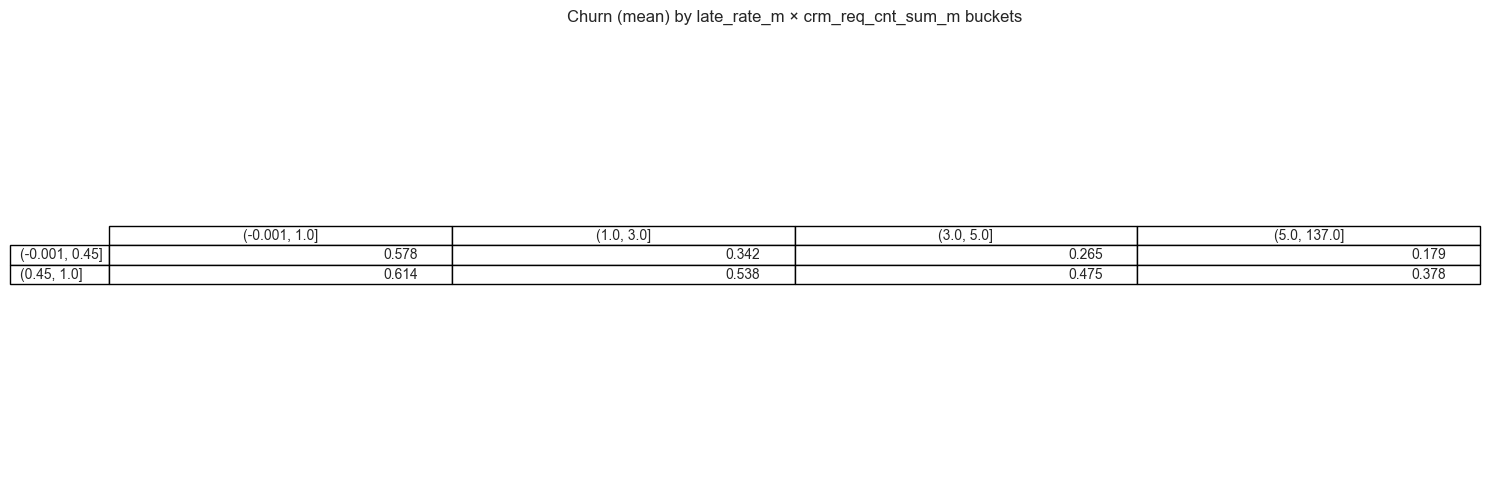


=== Quick Insight Summary ===
- Overall churn (active months): 0.540
- If churn rises as otd_rate_m deciles decrease and late_rate_m increase → delivery issues drive churn.
- If churn rises with crm_req_cnt_sum_m deciles → support friction is a strong driver.
- If churn rises with comment_neg_hits_m deciles → negative feedback correlates with churn.
- Tenure curve often shows higher churn among very new users (onboarding) or very old users (saturation).
- Cohort retention matrix: look for month-over-month decay; compare early vs recent cohorts.


In [ ]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

engine = create_engine(
    f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    future=True
)


cols = pd.read_sql("""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_schema='public' AND table_name='crm';
""", engine)
crm_cols = set(c.lower() for c in cols['column_name'])

def col_expr(possible_names):
    """Return 'NULLIF(c.<col>,'')::int' if any name exists; otherwise 'NULL'."""
    for name in possible_names:
        if name in crm_cols:
            return f"NULLIF(c.{name},'')::int"
    return "NULL"

customer_rate_expr = col_expr(["rate_to_shop", "customer_rate"])
courier_rate_expr  = col_expr(["rate_to_courier", "courier_rate"])

sql_user_month = rf"""
WITH
orders_clean AS (
  SELECT
    user_id,
    order_id,
    CASE
      WHEN NULLIF(order_date,'') ~ '^\d{{4}}-\d{{2}}-\d{{2}}([ T]\d{{2}}:\d{{2}}(:\d{{2}})?)?$'
      THEN (order_date)::timestamp ELSE NULL END AS order_ts,
    CASE
      WHEN lower(coalesce(is_otd,'')) IN ('1','true','t','yes','y') THEN 1
      WHEN lower(coalesce(is_otd,'')) IN ('0','false','f','no','n')  THEN 0
      ELSE NULL END AS is_otd_flag,
    lower(NULLIF(delivery_status,'')) AS delivery_status
  FROM public.orders
  WHERE coalesce(user_id,'')<>'' AND NULLIF(order_date,'')<>''
),
orders_month AS (
  SELECT
    user_id,
    order_id,
    date_trunc('month', order_ts)::date AS month_start,
    order_ts,
    is_otd_flag,
    delivery_status
  FROM orders_clean
  WHERE order_ts IS NOT NULL
),
orders_agg AS (
  SELECT
    user_id,
    month_start,
    COUNT(*) AS orders_cnt_m,
    AVG(is_otd_flag::float) AS otd_rate_m,
    1.0 - AVG(is_otd_flag::float) AS late_rate_m,
    AVG(CASE WHEN delivery_status='cancelled' THEN 1 ELSE 0 END) AS cancel_rate_m,
    AVG(CASE WHEN delivery_status='returned'  THEN 1 ELSE 0 END) AS return_rate_m,
    MAX(order_ts) AS last_order_ts_m
  FROM orders_month
  GROUP BY user_id, month_start
),
crm_clean AS (
  SELECT
    c.order_id,
    NULLIF(c.crm_delivery_request_count,'')::int AS crm_req_cnt,
    NULLIF(c.crm_fake_delivery_request_count,'')::int AS crm_fake_cnt,
    {customer_rate_expr} AS customer_rate,
    {courier_rate_expr}  AS courier_rate
  FROM public.crm c
),
crm_join AS (
  SELECT
    om.user_id,
    om.month_start,
    cc.crm_req_cnt,
    cc.crm_fake_cnt,
    cc.customer_rate,
    cc.courier_rate
  FROM orders_month om
  JOIN crm_clean cc USING (order_id)
),
crm_agg AS (
  SELECT
    user_id,
    month_start,
    COALESCE(SUM(crm_req_cnt), 0)  AS crm_req_cnt_sum_m,
    COALESCE(SUM(crm_fake_cnt), 0) AS crm_fake_cnt_sum_m,
    AVG(customer_rate)             AS customer_rate_avg_m,
    AVG(courier_rate)              AS courier_rate_avg_m
  FROM crm_join
  GROUP BY user_id, month_start
),
comments_join AS (
  SELECT
    om.user_id,
    om.month_start,
    lower(coalesce(cm.description,'')) AS desc_lc
  FROM public.comments cm
  JOIN orders_month om USING (order_id)
),
comments_agg AS (
  SELECT
    user_id,
    month_start,
    COUNT(*) AS comments_cnt_m,
    AVG(length(desc_lc))::float AS comment_avg_len_m,
    SUM( CASE WHEN desc_lc ~ '(bad|late|slow|cold|refund|missing|broken|fake|complain|angry|disappoint)' THEN 1 ELSE 0 END ) AS comment_neg_hits_m,
    SUM( CASE WHEN desc_lc ~ '(good|great|fast|fresh|hot|thank|love|awesome|perfect|nice)' THEN 1 ELSE 0 END ) AS comment_pos_hits_m
  FROM comments_join
  GROUP BY user_id, month_start
),
base AS (
  SELECT
    oa.user_id,
    oa.month_start,
    oa.orders_cnt_m,
    oa.otd_rate_m,
    oa.late_rate_m,
    oa.cancel_rate_m,
    oa.return_rate_m,
    COALESCE(cr.crm_req_cnt_sum_m, 0)     AS crm_req_cnt_sum_m,
    COALESCE(cr.crm_fake_cnt_sum_m, 0)    AS crm_fake_cnt_sum_m,
    cr.customer_rate_avg_m,
    cr.courier_rate_avg_m,
    COALESCE(cm.comments_cnt_m, 0)        AS comments_cnt_m,
    cm.comment_avg_len_m,
    COALESCE(cm.comment_neg_hits_m, 0)    AS comment_neg_hits_m,
    COALESCE(cm.comment_pos_hits_m, 0)    AS comment_pos_hits_m
  FROM orders_agg oa
  LEFT JOIN crm_agg      cr USING (user_id, month_start)
  LEFT JOIN comments_agg cm USING (user_id, month_start)
),
-- churn label: 1 if next month has zero orders, else 0
lbl AS (
  SELECT
    b.user_id,
    b.month_start,
    CASE WHEN COALESCE(n.orders_cnt_m, 0) = 0 THEN 1 ELSE 0 END AS label
  FROM base b
  LEFT JOIN base n
    ON n.user_id = b.user_id
   AND n.month_start = (b.month_start + INTERVAL '1 month')::date
)
SELECT
  b.*,
  l.label
FROM base b
JOIN lbl l USING (user_id, month_start)
WHERE b.orders_cnt_m > 0  -- define churn on active months
ORDER BY b.user_id, b.month_start;
"""

print("Reading user-month dataset from DB …")
df = pd.read_sql(sql_user_month, engine, parse_dates=["month_start"])
print("Shape:", df.shape)
print(df.head())

overall_churn = df['label'].mean()
print(f"\nOverall churn rate (active-months): {overall_churn:.3f}")

monthly_churn = df.groupby('month_start')['label'].mean().reset_index()
print("\nMonthly churn rate (head):")
print(monthly_churn.head())

plt.figure(figsize=(15, 5))
plt.plot(monthly_churn['month_start'], monthly_churn['label'])
plt.title("Monthly churn rate")
plt.xlabel("month")
plt.ylabel("churn rate")
plt.tight_layout()
plt.show()

# Cohorts
first_month = df.groupby('user_id')['month_start'].min().rename('cohort_month')
df_cohort = df.merge(first_month, on='user_id', how='left')
df_cohort['months_since_cohort'] = (
    (df_cohort['month_start'].dt.to_period('M') - df_cohort['cohort_month'].dt.to_period('M'))
).apply(lambda x: x.n)

activity = (df_cohort
            .groupby(['cohort_month','months_since_cohort','user_id'], as_index=False)
            .agg(active=('orders_cnt_m', lambda s: int(s.sum()>0))))

retention = (activity
             .groupby(['cohort_month','months_since_cohort'])['active']
             .mean()
             .reset_index()
             .pivot(index='cohort_month', columns='months_since_cohort', values='active')
             .fillna(0.0))

print("\nCohort retention matrix (rows=cohort month, cols=months since):")
print(retention.iloc[:, :7])

if len(retention) >= 2:
    plt.figure(figsize=(15, 5))
    for i, (idx, row) in enumerate(retention.iloc[:2].iterrows()):
        plt.plot(row.index.values, row.values, label=str(idx))
    plt.title("Retention curves for first 2 cohorts")
    plt.xlabel("months since cohort")
    plt.ylabel("retention")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Tenure
df_tenure = df_cohort.copy()
df_tenure['tenure_months'] = df_tenure['months_since_cohort']
tenure_rate = (df_tenure.groupby('tenure_months')['label'].mean().reset_index())
print("\nChurn rate by tenure (months since first order):")
print(tenure_rate.head(15))

plt.figure(figsize=(15, 5))
plt.plot(tenure_rate['tenure_months'], tenure_rate['label'])
plt.title("Churn rate by tenure")
plt.xlabel("tenure (months)")
plt.ylabel("churn rate")
plt.tight_layout()
plt.show()

# Binned relationships
def bin_churn(df_in, col, q=10):
    tmp = df_in.copy()
    x = tmp[col].astype(float)
    med = x.median() if np.isfinite(x).any() else 0.0
    tmp['_bin'] = pd.qcut(x.fillna(med), q=q, duplicates='drop')
    out = tmp.groupby('_bin')['label'].mean().reset_index()
    out.columns = ['bin', 'churn_rate']
    out['feature'] = col
    return out

to_check = ['orders_cnt_m', 'otd_rate_m', 'late_rate_m', 'crm_req_cnt_sum_m', 'comment_neg_hits_m']
bin_results = pd.concat([bin_churn(df, c) for c in to_check], ignore_index=True)

for col in to_check:
    sub = bin_results[bin_results['feature'] == col]
    print(f"\nChurn by {col} deciles:")
    print(sub)

for col in ['otd_rate_m', 'crm_req_cnt_sum_m', 'comment_neg_hits_m']:
    sub = bin_results[bin_results['feature'] == col]
    plt.figure(figsize=(15, 5))
    plt.plot(range(len(sub)), sub['churn_rate'].values)
    plt.title(f"Churn vs {col} (deciles)")
    plt.xlabel("decile (low→high)")
    plt.ylabel("churn rate")
    plt.tight_layout()
    plt.show()

# Correlations
feature_cols = [
    'orders_cnt_m','otd_rate_m','late_rate_m','cancel_rate_m','return_rate_m',
    'crm_req_cnt_sum_m','crm_fake_cnt_sum_m','customer_rate_avg_m','courier_rate_avg_m',
    'comments_cnt_m','comment_avg_len_m','comment_neg_hits_m','comment_pos_hits_m'
]
corrs = []
for c in feature_cols:
    try:
        corrs.append((c, np.corrcoef(df[c].fillna(0).astype(float), df['label'].astype(float))[0,1]))
    except Exception:
        corrs.append((c, np.nan))
corr_df = pd.DataFrame(corrs, columns=['feature','pearson_corr_with_label']).sort_values('pearson_corr_with_label', ascending=False)
print("\nFeature ↔ label Pearson correlations (approx point-biserial):")
print(corr_df)

# Interaction table
def bucketize(s, bins):
    edges = np.quantile(s.fillna(s.median()), bins)
    return pd.cut(s, bins=np.unique(edges), include_lowest=True, duplicates='drop')

df_inter = df.copy()
df_inter['late_bucket'] = bucketize(df_inter['late_rate_m'].astype(float), [0, .2, .4, .6, .8, 1.0])
df_inter['crm_bucket'] = bucketize(df_inter['crm_req_cnt_sum_m'].astype(float), [0, .5, .75, .9, .95, 1.0])

pivot = df_inter.pivot_table(
    index='late_bucket',
    columns='crm_bucket',
    values='label',
    aggfunc='mean'
)
print("\nChurn heatmap table (late_rate_m bucket × crm_req_cnt_sum_m bucket):")
print(pivot)

plt.figure(figsize=(15, 5))
ax = plt.gca()
ax.axis('off')
tbl = plt.table(
    cellText=np.round(pivot.values, 3),
    rowLabels=[str(i) for i in pivot.index],
    colLabels=[str(c) for c in pivot.columns],
    loc='center'
)
plt.title("Churn (mean) by late_rate_m × crm_req_cnt_sum_m buckets")
plt.tight_layout()
plt.show()

# Summary
print("\n=== Quick Insight Summary ===")
print(f"- Overall churn (active months): {overall_churn:.3f}")
print("- If churn rises as otd_rate_m deciles decrease and late_rate_m increase → delivery issues drive churn.")
print("- If churn rises with crm_req_cnt_sum_m deciles → support friction is a strong driver.")
print("- If churn rises with comment_neg_hits_m deciles → negative feedback correlates with churn.")
print("- Tenure curve often shows higher churn among very new users (onboarding) or very old users (saturation).")
print("- Cohort retention matrix: look for month-over-month decay; compare early vs recent cohorts.")


---
## Executive Summary (from EDA Outputs)

### Overall Churn
- **Overall churn (active months): 54.0%** — high. Retention improvement is needed.  
- **By month:** churn rises into **May (56.5%)**, then improves (e.g., **July 35.2%**).  
  > Possible drivers: seasonality or operational changes.

---

### Cohorts
- Clear **right-censoring** — later cohorts have fewer months observed.  
- **Early cohorts** maintain activity longer than newer ones.  
- The zeros at later columns mainly reflect **observation cutoff**, not true churn.

---

### Tenure
- **Very high early churn:** month 0 → **67.1%**.  
- Improves around months **2–3 (~36–34%)**.  
- Jumps again around months **5–6** — likely a **data-window effect / censoring**.

---

### Engagement
- **More orders → lower churn.**  
  - From **67%** churn (1–2 orders) down to **12.8%** (7+ orders).  
- Indicates **habit formation** is critical for retention.

---

### Delivery Quality
- **Naïve binned view looks “U-shaped”** — driven by confounding with engagement.  
  - Example: `otd_rate_m = 1` often occurs when only one order exists (low engagement).  
- When **controlling for engagement**, **late deliveries still raise churn**  
  (validated in the interaction heatmap).

---

### CRM Tickets
- **Higher CRM volume months → lower churn** in this cut:  
  - 3+ requests → **28.7% churn**  
  - 0–1 requests → **59.1% churn**  
- Likely due to **engaged users contacting support more**, not tickets being positive.  
  - Use **normalized CRM per order** to decouple activity vs friction.

---

### Comments
- `comment_neg_hits_m` returned **empty**, suggesting:  
  - Few textual comments, or  
  - Keyword list mismatch (different language).  
- Action: apply **language-appropriate sentiment lexicon** or **Python NLP (VADER/transformers)**.

---

### Correlations (Feature → Label)
> Higher magnitude → stronger predictive power

| Feature | Correlation | Interpretation |
|----------|--------------|----------------|
| `customer_rate_avg_m` | **-0.239** | Higher customer ratings → lower churn |
| `courier_rate_avg_m` | **-0.197** | Higher courier ratings → lower churn |
| `crm_req_cnt_sum_m` | **-0.196** | Proxy for engagement |
| `orders_cnt_m` | **-0.084** | More orders → lower churn |
| `cancel_rate_m`, `return_rate_m` | *NaN* | Near-zero variance; remove or aggregate |
| `comment_neg_hits_m` | *NaN* | No data / mismatched text parsing |

---

### Interaction Heatmap (`late_rate_m × crm_req_cnt_sum_m`)
- **Higher late rate ⇒ higher churn** across all CRM levels.  
- Within each late-rate bucket, **more CRM → lower churn**, consistent with engagement.

---

 **Summary Takeaways**
- Delivery experience and satisfaction ratings are key churn drivers.  
- Engagement intensity (orders, CRM) reduces churn.  
- Early-life churn (onboarding) is the steepest loss point.  
- Comments data currently underused — add NLP-derived sentiment.  


-----
# Suggested features:

## Modeling Setup (User × Month)

Use **per user × month** as the modeling unit (only months where the user ordered), and predict **no order next month**.

---

### Engagement & Habit
- `orders_cnt_m` — count this month  
- `orders_cnt_3m`, `orders_cnt_6m` — rolling sums  
- `months_active_6m` — distinct active months in last 6  
- `recency_days` — days since last order at month-end  
- `tenure_months` — months since first order  

---

### Delivery Quality
- `otd_rate_m`, `late_rate_m` — this month  
- `otd_rate_3m`, `late_rate_3m` — rolling means  
- `cancel_rate_3m`, `return_rate_3m` — rolling means (monthly values are sparse)

---

### Support Friction (Normalized & Raw)
- `crm_req_cnt_sum_m`, `crm_fake_cnt_sum_m` — monthly sums  
- Normalize by orders:  
  `crm_req_per_order_m = crm_req_cnt_sum_m / NULLIF(orders_cnt_m, 0)`  
- Rolling:  
  `crm_req_per_order_3m`, `crm_req_cnt_sum_3m`

---

### Satisfaction (Ratings)
- `customer_rate_avg_m`, `courier_rate_avg_m` — monthly averages  
- Rolling means: `_3m`

---

### Voice of Customer (if comments present)
- `comments_cnt_m`, `comment_avg_len_m`  
- *(Optional later)* `vader_neg_avg_m`, `vader_pos_avg_m` from Python, or TF-IDF/embeddings  
  > Note: current keyword hits are empty; use language-appropriate NLP.

---

### Simple Interactions (for linear models)
- `late_rate_m * orders_cnt_m`  
- `crm_req_per_order_m * late_rate_m`

---

### Label & Data Hygiene
- `label = 1` if **no orders in m+1**, else `0`.  
- Exclude the **last calendar month** from training labels (right-censoring).  
- Drop features with **near-zero variance** (e.g., `cancel_rate_m` if always 0).
